# Component 4 — Rules vs ML vs Hybrid for agency-banking anomaly detection

**Research question.** For flagging suspicious agency-banking transactions, is a hybrid of the CBSL
rule and the ML model better than either one alone?

The live system (`backend/src/controllers/agencyBanking.controller.js`) flags a transaction when
**the ML model says anomaly OR the amount reaches the CBSL rural-agent daily limit**. This notebook
measures whether that design choice is justified.

Compared on the **same held-out test set** (20 %, never used to choose anything):

| | Method | What it is |
|---|---|---|
| N | Naive: flag every `transfer` | The simplest possible baseline |
| A | CBSL rule only | amount ≥ CBSL daily limit for the transaction type |
| B | Z-score rule only | amount more than 2 standard deviations from the usual (abs z > 2) |
| C | ML only, threshold 0.5 | the original default |
| D | ML only, threshold 0.86 | threshold chosen on training data in `agency_banking_threshold.ipynb` |
| E | **Hybrid: D OR A** | **what the live system does** |
| F | Hybrid: D AND A | flag only when both agree |

No parameter is tuned on the test set: the limits come from the backend, 0.86 from the threshold
notebook. The original notebooks, dataset and `.pkl` are not changed.

In [1]:
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

## 1. Same data and split as `agency banking.ipynb`

In [2]:
bundle = joblib.load('component4_banking_anomaly_model.pkl')
champion = bundle['champion_model']

df = pd.read_csv('paysim.csv').drop_duplicates().reset_index(drop=True)
df = df.drop(columns=['bank_txn_id', 'date'], errors='ignore')
df['is_high_zscore'] = (df['amount_zscore'].abs() > 2.0).astype(int)

y = df['target_anomaly'].astype(int)
X = df.drop(columns=['target_anomaly'])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
X_test = X_test.copy()

num = bundle['iso_imputer'].transform(X_test[bundle['iso_num_cols']])
X_test['unsupervised_anomaly_score'] = (bundle['iso_forest'].predict(num) == -1).astype(int)

cols = list(champion.feature_names_in_)
y_true = y_test.to_numpy()
print(f'Test set: {len(X_test)} transactions, {y_true.sum()} anomalies ({y_true.mean():.1%})')
print('Anomalies by transaction type (whole dataset):')
print(df.groupby('txn_type')['target_anomaly'].agg(transactions='size', anomaly_rate='mean').round(3))

Test set: 32852 transactions, 1643 anomalies (5.0%)
Anomalies by transaction type (whole dataset):
          transactions  anomaly_rate
txn_type                            
cash_in          34663          0.00
cash_out         58723          0.07
debit              989          0.00
payment          52826          0.00
transfer         17059          0.24


## 2. The flags of each method

CBSL limits are the rural (low-volume) agent tier used in the backend: cash deposit LKR 50,000,
cash withdrawal LKR 25,000, fund transfer LKR 50,000. In this dataset `cash_in` = deposit,
`cash_out` = withdrawal, `transfer` = fund transfer; `payment` and `debit` have no CBSL agent limit.

In [3]:
ML_THRESHOLD = 0.86   # chosen on training data only (agency_banking_threshold.ipynb)
CBSL_LIMIT_RS = {'cash_in': 50_000, 'cash_out': 25_000, 'transfer': 50_000}

p_ml = champion.predict_proba(X_test[cols])[:, 1]
limit = X_test['txn_type'].map(CBSL_LIMIT_RS)
cbsl = (X_test['amount_abs_rs'] >= limit).to_numpy()          # NaN limit (payment/debit) -> False
ml_086 = p_ml >= ML_THRESHOLD

flags = {
    'N. Naive: every transfer':     (X_test['txn_type'] == 'transfer').to_numpy(),
    'A. CBSL rule only':            cbsl,
    'B. Z-score rule only':         (X_test['is_high_zscore'] == 1).to_numpy(),
    'C. ML only (0.5)':             p_ml >= 0.5,
    'D. ML only (0.86)':            ml_086,
    'E. Hybrid: ML OR CBSL (live)': ml_086 | cbsl,
    'F. Hybrid: ML AND CBSL':       ml_086 & cbsl,
}

## 3. Results on the test set

- **Precision**: of the transactions flagged, how many were really anomalies.
- **Recall**: of the real anomalies, how many were flagged.
- **F1** = 2 × precision × recall / (precision + recall): one number that is high only when both are high.
  Accuracy is not used: with 5 % anomalies, flagging nothing already gives 95 % accuracy.
- **False alarms per 1,000 normal**: how often an honest customer is flagged — what the agent feels.

In [4]:
def scores(y_true, flag):
    tn, fp, fn, tp = confusion_matrix(y_true, flag, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {'TP': tp, 'FP': fp, 'FN': fn, 'precision': precision, 'recall': recall, 'F1': f1,
            'false alarms / 1000 normal': fp / (fp + tn) * 1000,
            'flagged %': (tp + fp) / len(y_true) * 100}

results = pd.DataFrame({name: scores(y_true, f) for name, f in flags.items()}).T
num_cols = ['precision', 'recall', 'F1', 'false alarms / 1000 normal', 'flagged %']
results[num_cols] = results[num_cols].astype(float).round(3)
results

,TP,FP,FN,precision,recall,F1,false alarms / 1000 normal,flagged %
N. Naive: every transfer,820.0,2550.0,823.0,0.243,0.499,0.327,81.707,10.258
A. CBSL rule only,1500.0,18058.0,143.0,0.077,0.913,0.142,578.615,59.534
B. Z-score rule only,248.0,863.0,1395.0,0.223,0.151,0.180,27.652,3.382
C. ML only (0.5),1279.0,4253.0,364.0,0.231,0.778,0.357,136.275,16.839
D. ML only (0.86),694.0,660.0,949.0,0.513,0.422,0.463,21.148,4.122
E. Hybrid: ML OR CBSL (live),1576.0,18184.0,67.0,0.080,0.959,0.147,582.652,60.149
F. Hybrid: ML AND CBSL,618.0,534.0,1025.0,0.536,0.376,0.442,17.110,3.507


## 4. Is the difference real? Bootstrap 95 % confidence intervals

The test set is resampled 1,000 times (with replacement). If the 95 % interval of the F1 difference
does not include 0, the difference is unlikely to be luck of this particular test set.

In [5]:
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.integers(0, len(y_true), size=(1000, len(y_true)))

def f1_of(y, f):
    tp = (y & f).sum(axis=1); fp = (~y & f).sum(axis=1); fn = (y & ~f).sum(axis=1)
    return 2 * tp / np.maximum(2 * tp + fp + fn, 1)

yb = y_true.astype(bool)[idx]
boot = {name: f1_of(yb, f.astype(bool)[idx]) for name, f in flags.items()}

def ci(a):
    lo, hi = np.percentile(a, [2.5, 97.5])
    return f'{a.mean():+.3f}  [{lo:+.3f}, {hi:+.3f}]'

base = 'D. ML only (0.86)'
for name in ['A. CBSL rule only', 'E. Hybrid: ML OR CBSL (live)', 'F. Hybrid: ML AND CBSL', 'N. Naive: every transfer']:
    print(f'F1({name}) - F1({base}): {ci(boot[name] - boot[base])}')

F1(A. CBSL rule only) - F1(D. ML only (0.86)): -0.322  [-0.344, -0.300]
F1(E. Hybrid: ML OR CBSL (live)) - F1(D. ML only (0.86)): -0.316  [-0.337, -0.294]
F1(F. Hybrid: ML AND CBSL) - F1(D. ML only (0.86)): -0.021  [-0.031, -0.011]
F1(N. Naive: every transfer) - F1(D. ML only (0.86)): -0.136  [-0.161, -0.111]


## 5. What does the CBSL rule add to the ML model?

Transactions flagged by the CBSL rule **but not** by the ML model are exactly what the hybrid adds.
How many of them are real anomalies, by transaction type?

In [6]:
added = cbsl & ~ml_086
breakdown = (pd.DataFrame({'txn_type': X_test['txn_type'].to_numpy()[added], 'anomaly': y_true[added]})
             .groupby('txn_type')['anomaly'].agg(added_flags='size', real_anomalies='sum'))
breakdown['false_alarms'] = breakdown['added_flags'] - breakdown['real_anomalies']
print(f'The hybrid adds {added.sum()} flags: {y_true[added].sum()} real anomalies, '
      f'{(1 - y_true[added]).sum()} honest customers.')
breakdown

The hybrid adds 18406 flags: 882 real anomalies, 17524 honest customers.


,added_flags,real_anomalies,false_alarms
txn_type,,,
cash_in,5729,0,5729
cash_out,10256,412,9844
transfer,2421,470,1951


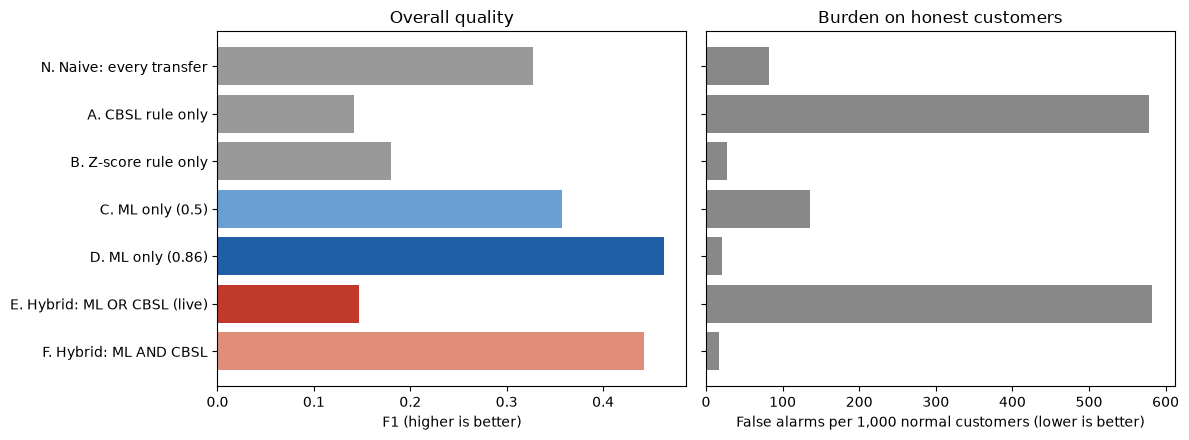

In [7]:
order = list(flags)
r = results.loc[order]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].barh(r.index, r['F1'], color=['#999'] * 3 + ['#6a9fd4', '#1f5fa8', '#c0392b', '#e08e79'])
ax[0].set_xlabel('F1 (higher is better)'); ax[0].invert_yaxis(); ax[0].set_title('Overall quality')
ax[1].barh(r.index, r['false alarms / 1000 normal'], color='#888')
ax[1].set_xlabel('False alarms per 1,000 normal customers (lower is better)'); ax[1].invert_yaxis()
ax[1].set_yticklabels([]); ax[1].set_title('Burden on honest customers')
plt.tight_layout(); plt.savefig('component4_hybrid_comparison.png', dpi=120); plt.show()

## 6. Conclusion

*Written after reading the numbers above — fill in with the actual results:*

- Best method by F1: ___ (F1 ___). Live hybrid (E): F1 ___, false alarms ___ per 1,000.
- Does the CBSL rule improve on ML alone? ___ (bootstrap interval ___).
- Where the rule helps / hurts (section 5): ___.

**Limitations.** PaySim is a *simulated* mobile-money dataset, not Sri Lankan agency-banking records;
its amounts are much larger than rural agent transactions, which affects how often the CBSL rule
fires. The comparison of methods on the same data is valid; the absolute numbers are not a claim
about real-world performance.